In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset
df = pd.read_csv("../data/processed/customer_churn_cleaned.csv")

print("EDA Dataset Loaded Successfully!")
print("Shape:", df.shape)

df.head()

EDA Dataset Loaded Successfully!
Shape: (7043, 33)


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


Churn Counts:
Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentage:
Churn Label
No     73.46
Yes    26.54
Name: proportion, dtype: float64


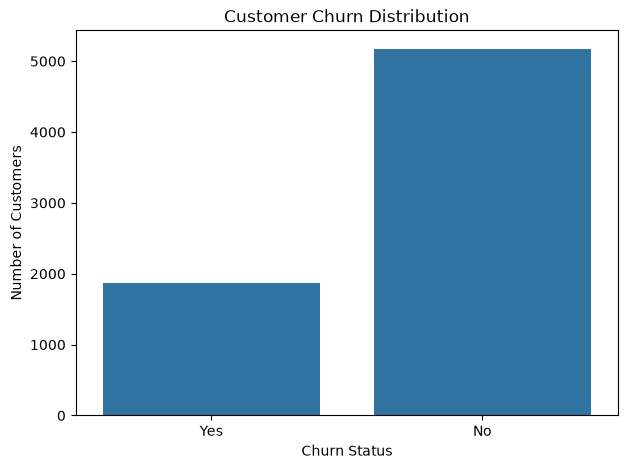

In [2]:
# Overall Churn Analysis

churn_counts = df["Churn Label"].value_counts()
churn_percentage = df["Churn Label"].value_counts(normalize=True) * 100

print("Churn Counts:")
print(churn_counts)

print("\nChurn Percentage:")
print(churn_percentage.round(2))

# Visualization
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Churn Label")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

plt.show()

Churn Percentage by Contract Type:
Churn Label        No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83


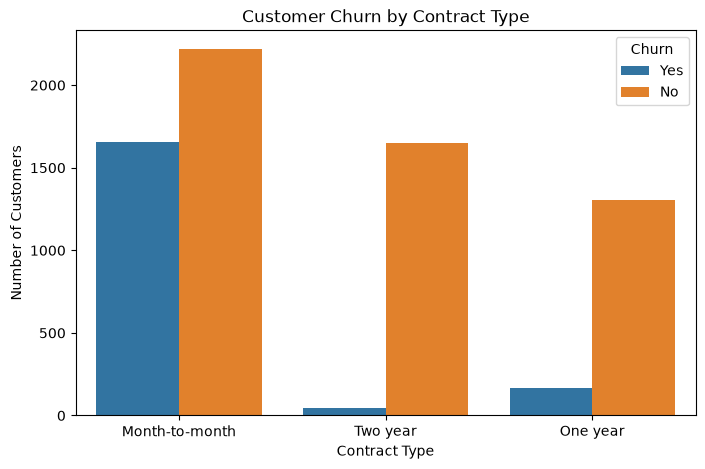

In [3]:
# Contract Type vs Churn

contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn Label"],
    normalize="index"
) * 100

print("Churn Percentage by Contract Type:")
print(contract_churn.round(2))

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn Label"
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")

plt.show()

Average Tenure by Churn Status:
Churn Label
No     37.57
Yes    17.98
Name: Tenure Months, dtype: float64


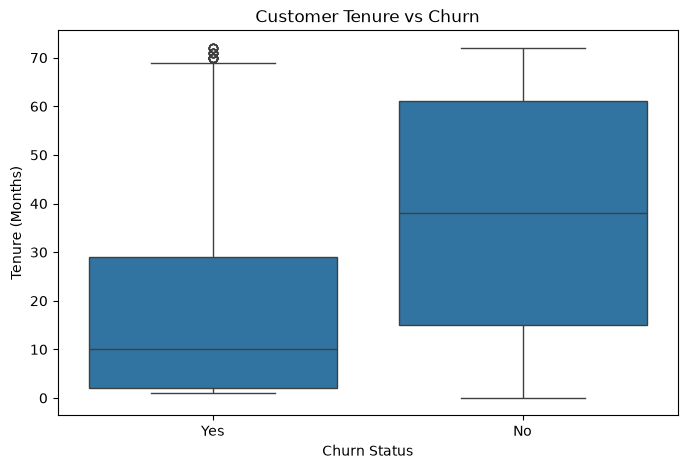

In [4]:
# Customer Tenure vs Churn

print("Average Tenure by Churn Status:")
print(df.groupby("Churn Label")["Tenure Months"].mean().round(2))

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn Label",
    y="Tenure Months"
)

plt.title("Customer Tenure vs Churn")
plt.xlabel("Churn Status")
plt.ylabel("Tenure (Months)")

plt.show()

Average Monthly Charges by Churn Status:
Churn Label
No     61.27
Yes    74.44
Name: Monthly Charges, dtype: float64


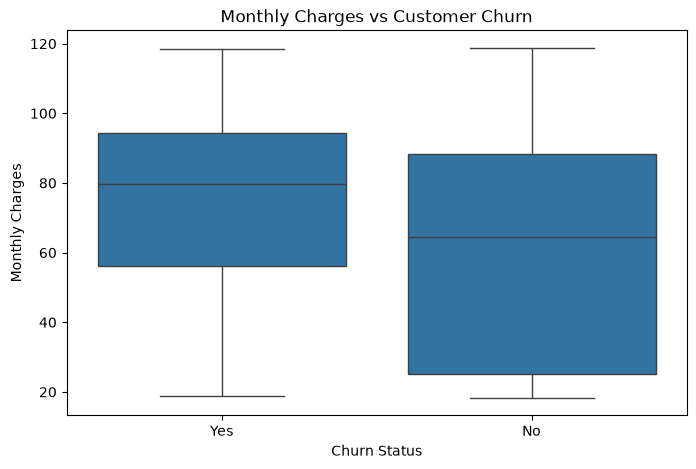

In [5]:
# Monthly Charges vs Churn

print("Average Monthly Charges by Churn Status:")
print(df.groupby("Churn Label")["Monthly Charges"].mean().round(2))

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn Label",
    y="Monthly Charges"
)

plt.title("Monthly Charges vs Customer Churn")
plt.xlabel("Churn Status")
plt.ylabel("Monthly Charges")

plt.show()

Churn Percentage by Payment Method:
Churn Label                   No    Yes
Payment Method                         
Bank transfer (automatic)  83.29  16.71
Credit card (automatic)    84.76  15.24
Electronic check           54.71  45.29
Mailed check               80.89  19.11


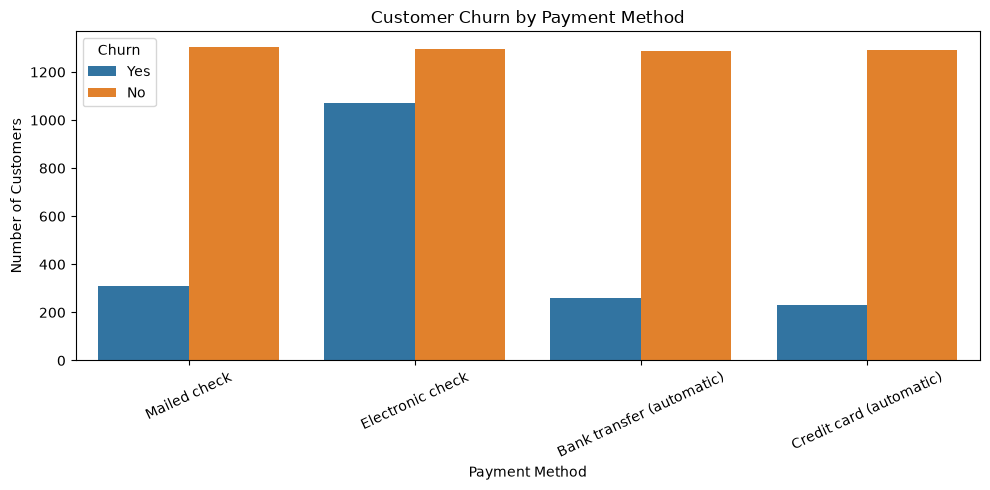

In [6]:
# Payment Method vs Churn

payment_churn = pd.crosstab(
    df["Payment Method"],
    df["Churn Label"],
    normalize="index"
) * 100

print("Churn Percentage by Payment Method:")
print(payment_churn.round(2))

plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="Payment Method",
    hue="Churn Label"
)

plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=25)
plt.legend(title="Churn")

plt.tight_layout()
plt.show()

Churn Percentage by Internet Service:
Churn Label          No    Yes
Internet Service              
DSL               81.04  18.96
Fiber optic       58.11  41.89
No                92.60   7.40


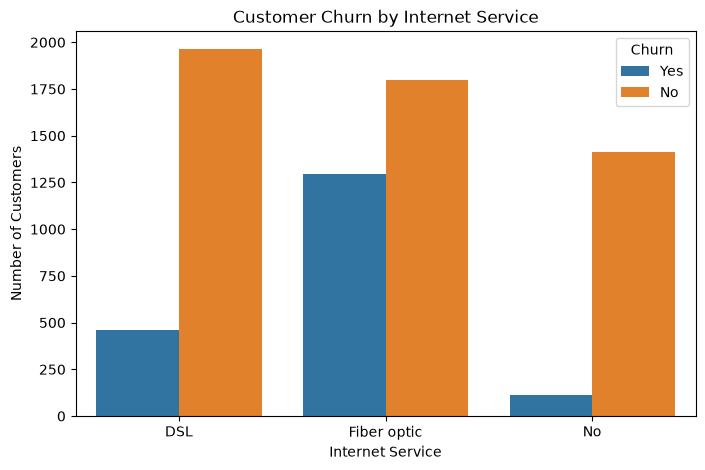

In [7]:
# Internet Service vs Churn

internet_churn = pd.crosstab(
    df["Internet Service"],
    df["Churn Label"],
    normalize="index"
) * 100

print("Churn Percentage by Internet Service:")
print(internet_churn.round(2))

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Internet Service",
    hue="Churn Label"
)

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")

plt.show()

Top 10 Churn Reasons:
Churn Reason
Attitude of support person                   192
Competitor offered higher download speeds    189
Competitor offered more data                 162
Don't know                                   154
Competitor made better offer                 140
Attitude of service provider                 135
Competitor had better devices                130
Network reliability                          103
Product dissatisfaction                      102
Price too high                                98
Name: count, dtype: int64


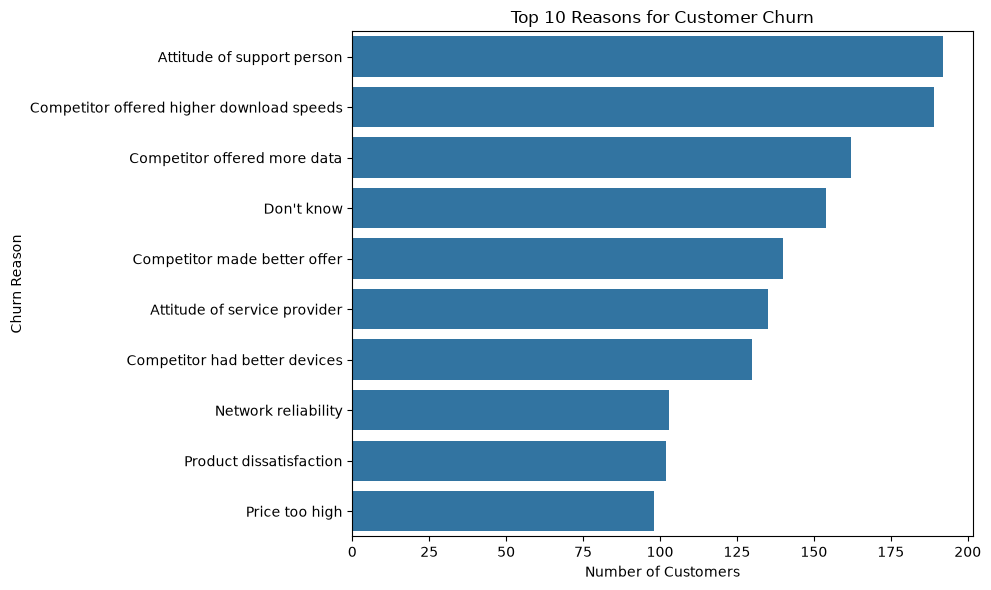

In [8]:
churned = df[df["Churn Label"] == "Yes"]

top_reasons = churned["Churn Reason"].value_counts().head(10)

print("Top 10 Churn Reasons:")
print(top_reasons)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_reasons.values, y=top_reasons.index)

plt.title("Top 10 Reasons for Customer Churn")
plt.xlabel("Number of Customers")
plt.ylabel("Churn Reason")
plt.tight_layout()
plt.show()

Churn Label        No    Yes
Senior Citizen              
No              76.39  23.61
Yes             58.32  41.68


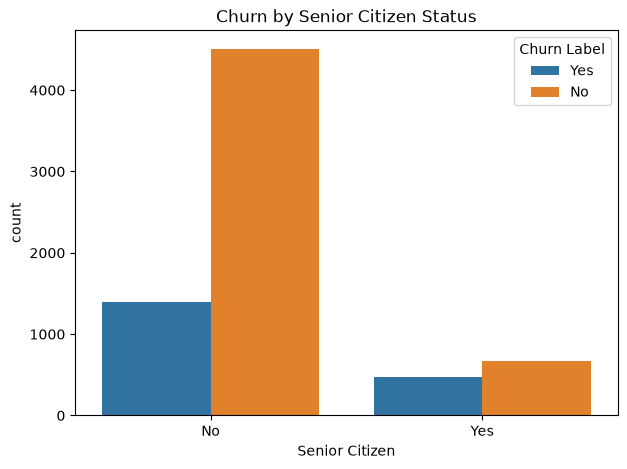

In [9]:
senior_churn = pd.crosstab(
    df["Senior Citizen"],
    df["Churn Label"],
    normalize="index"
) * 100

print(senior_churn.round(2))

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Senior Citizen", hue="Churn Label")
plt.title("Churn by Senior Citizen Status")
plt.show()